# Kneeplot for COLO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import math
import scanpy as sc

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [ ]:
dna_barcodes = pd.read_csv("/barcodes/cellranger_arc_atac.737K-arc-v1.txt",  header=None)
rna_barcodes = pd.read_csv("/barcodes/cellranger_arc_rna.737K-arc-v1.txt", header=None)
matched_barcodes = pd.concat([dna_barcodes, rna_barcodes], axis=1)
matched_barcodes.columns = ["atac_barcode", "cDNA_barcode"]


# Scatter with colors - actually used

In [ ]:
# get atac and rna objects
rna = sc.read_h5ad("/COLO829_adata_05052026.h5ad")
atac = sc.read_h5ad("/atac/COLO/outs/20260511_atac_ball_processed.h5ad")

In [5]:
rna

AnnData object with n_obs × n_vars = 5183 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'outlier', 'mt_outlier', 'ribo_outlier', 'phase', 'S_score', 'G2M_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_pre_harmony'
    varm: 'PCs'
    layers: 'counts', 'log_counts'
    obsp: 'connectivities', 'distances'

In [6]:
atac.obs.total_fragments_count.min()

1914

In [7]:
atac

AnnData object with n_obs × n_vars = 6273 × 365588
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'barcode_rank', 'total_fragments_count', 'log10_total_fragments_count', 'unique_fragments_count', 'log10_unique_fragments_count', 'total_fragments_in_peaks_count', 'log10_total_fragments_in_peaks_count', 'unique_fragments_in_peaks_count', 'log10_unique_fragments_in_peaks_count', 'fraction_of_fragments_in_peaks', 'duplication_count', 'duplication_ratio', 'nucleosome_signal', 'tss_enrichment', 'pdf_values_for_tss_enrichment', 'pdf_values_for_fraction_of_fragments_in_peaks', 'pdf_values_for_duplication_ratio', 'barcode', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'outlier', 'mt_outlier', 'ribo_outlier', 'phase', 'S_score', 'G2M_score', 'base_index', 'atac_CB', 'pycisTopic_leiden_10_0.2', 'pycisTopic

In [8]:
rna.obs['CB_rna'] = rna.obs.index.str.replace('-.*','', regex = True)
rna.obs['CB_rna']

AAACCAACAAGGTAAC-COLO829BL       AAACCAACAAGGTAAC
AAACCGCGTACCAGGT-COLO829BL       AAACCGCGTACCAGGT
AAACCGCGTTCCGCAC-COLO829BL       AAACCGCGTTCCGCAC
AAACCGCGTTGCTGGG-COLO829BL       AAACCGCGTTGCTGGG
AAACCGGCATGCTCCC-COLO829BL       AAACCGGCATGCTCCC
                                       ...       
TTTGTGAAGAGCCGGA-COLO829_rep2    TTTGTGAAGAGCCGGA
TTTGTGAAGCAGGTGG-COLO829_rep2    TTTGTGAAGCAGGTGG
TTTGTGAAGTTTAACG-COLO829_rep2    TTTGTGAAGTTTAACG
TTTGTGGCATGTTGGC-COLO829_rep2    TTTGTGGCATGTTGGC
TTTGTGTTCCTCCTAA-COLO829_rep2    TTTGTGTTCCTCCTAA
Name: CB_rna, Length: 5183, dtype: object

In [9]:
atac.obs['CB'] = atac.obs.index
atac.obs['sample'] = atac.obs['sample_id']

In [ ]:
dna_barcodes = pd.read_csv("/barcodes/cellranger_arc_atac.737K-arc-v1.txt", header=None)
rna_barcodes = pd.read_csv("/barcodes/cellranger_arc_rna.737K-arc-v1.txt", header=None)
matched_barcodes = pd.concat([dna_barcodes, rna_barcodes], axis=1)
matched_barcodes.columns = ["atac_barcode", "cDNA_barcode"]
barcode_map = dict(zip(matched_barcodes['cDNA_barcode'], matched_barcodes['atac_barcode']))
rna.obs['CB'] = rna.obs['CB_rna'].map(barcode_map)
rna.obs['CB'] = rna.obs['CB'].astype(str)  + '-' + rna.obs['sample'].astype(str) + '___'+rna.obs['sample'].astype(str) 


In [14]:
rna.obs['CB']

AAACCAACAAGGTAAC-COLO829BL             CTTTATCGTTAGCTAC-COLO829BL___COLO829BL
AAACCGCGTACCAGGT-COLO829BL             AATAGCTCATAATCGG-COLO829BL___COLO829BL
AAACCGCGTTCCGCAC-COLO829BL             AATAGCTCATGAGGGA-COLO829BL___COLO829BL
AAACCGCGTTGCTGGG-COLO829BL             AATAGCTCACTCAGTT-COLO829BL___COLO829BL
AAACCGGCATGCTCCC-COLO829BL             ATTGACCGTAGTAGCA-COLO829BL___COLO829BL
                                                     ...                     
TTTGTGAAGAGCCGGA-COLO829_rep2    GTAGGTGTCATGGATA-COLO829_rep2___COLO829_rep2
TTTGTGAAGCAGGTGG-COLO829_rep2    GTAGGTGTCGCGACTT-COLO829_rep2___COLO829_rep2
TTTGTGAAGTTTAACG-COLO829_rep2    GTAGGTGTCAAGCGCA-COLO829_rep2___COLO829_rep2
TTTGTGGCATGTTGGC-COLO829_rep2    GTTTGGTGTGCTTCCT-COLO829_rep2___COLO829_rep2
TTTGTGTTCCTCCTAA-COLO829_rep2    GTTCTCAAGAAGGGTA-COLO829_rep2___COLO829_rep2
Name: CB, Length: 5183, dtype: object

In [15]:
merged_df = pd.merge(rna.obs, atac.obs, on='CB', how='outer', 
                     indicator = True)
custom_mapping = {
    'left_only': 'RNA_only',
    'right_only': 'ATAC_only',
    'both': 'Multiome'
}
merged_df['_merge'] = merged_df['_merge'].map(custom_mapping)

In [16]:
merged_df

/opt/venv/lib/python3.11/site-packages/IPython/lib/pretty.py:779: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  output = repr(obj)
/opt/venv/lib/python3.11/site-packages/IPython/core/formatters.py:347: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return method()


,sample_x,n_genes_by_counts_x,log1p_n_genes_by_counts_x,total_counts_x,log1p_total_counts_x,pct_counts_in_top_20_genes_x,pct_counts_mt_x,pct_counts_ribo_x,pct_counts_hb_x,outlier_x,...,G2M_score_y,base_index,atac_CB,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,_merge
0,COLO829BL,4131.0,8.326517,21395.0,9.970960,26.422061,3.271792,2.009815,0.0,False,...,-0.417121,AAACCAACAAGGTAAC,CTTTATCGTTAGCTAC,2,2,6,7,30,51,Multiome
1,COLO829BL,4500.0,8.412055,20423.5,9.924491,16.583837,6.208534,2.085833,0.0,False,...,1.363847,AAACCGCGTACCAGGT,AATAGCTCATAATCGG,2,2,6,11,20,42,Multiome
2,COLO829BL,4315.0,8.370084,18555.0,9.828548,17.078954,0.711399,1.794665,0.0,False,...,0.219088,AAACCGCGTTCCGCAC,AATAGCTCATGAGGGA,2,2,6,11,22,4,Multiome
3,COLO829BL,1451.0,7.280697,5508.0,8.614139,31.989833,3.031954,3.721859,0.0,False,...,-0.462720,AAACCGCGTTGCTGGG,AATAGCTCACTCAGTT,2,2,3,7,33,21,Multiome
4,COLO829BL,5112.0,8.539542,26430.5,10.182312,14.982690,5.716880,3.613250,0.0,False,...,0.497705,AAACCGGCATGCTCCC,ATTGACCGTAGTAGCA,2,2,3,7,25,27,Multiome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,3,27,70,ATAC_only
6832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,8,24,73,ATAC_only
6833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,8,24,73,ATAC_only
6834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,3,4,1,4,12,ATAC_only


In [19]:
merged_df['sample_id'].value_counts().sum()

6273

In [20]:
merged_df['sample_complete'] = merged_df['sample_x'].combine_first(merged_df['sample_y'])

In [21]:
merged_df[merged_df['sample_x'] != merged_df['sample_y']]

/opt/venv/lib/python3.11/site-packages/IPython/lib/pretty.py:779: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  output = repr(obj)
/opt/venv/lib/python3.11/site-packages/IPython/core/formatters.py:347: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return method()


,sample_x,n_genes_by_counts_x,log1p_n_genes_by_counts_x,total_counts_x,log1p_total_counts_x,pct_counts_in_top_20_genes_x,pct_counts_mt_x,pct_counts_ribo_x,pct_counts_hb_x,outlier_x,...,base_index,atac_CB,pycisTopic_leiden_10_0.2,pycisTopic_leiden_10_0.3,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,pycisTopic_leiden_10_6,_merge,sample_complete
8,COLO829BL,2316.0,7.748029,7321.000000,8.898639,10.422073,4.603196,3.933889,0.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RNA_only,COLO829BL
13,COLO829BL,2528.0,7.835579,9815.000000,9.191769,18.869078,4.768212,4.065206,0.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RNA_only,COLO829BL
22,COLO829BL,2807.0,7.940228,9572.000000,9.166702,11.220226,4.993732,2.778939,0.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RNA_only,COLO829BL
24,COLO829BL,2840.0,7.951911,13014.482422,9.473895,26.870066,12.570611,3.211807,0.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RNA_only,COLO829BL
56,COLO829BL,3050.0,8.023225,10376.500000,9.247396,9.299860,1.985255,4.249988,0.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RNA_only,COLO829BL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,3,27,70,ATAC_only,COLO829_rep2
6832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,8,24,73,ATAC_only,COLO829_rep2
6833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,8,24,73,ATAC_only,COLO829_rep2
6834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,3,4,1,4,12,ATAC_only,COLO829_rep2


In [22]:
merged_df[merged_df['sample_x'] != merged_df['sample_y']]['sample_x'].isna().sum()

1653

In [23]:
merged_df[merged_df['sample_x'] != merged_df['sample_y']]['sample_y'].isna().sum()

563

In [24]:
merged_df['sample_complete'].value_counts()

COLO829_rep2    2772
COLO829_rep1    2519
COLO829BL       1545
Name: sample_complete, dtype: int64

In [25]:
merged_df['sample_complete'].isna().sum()

0

In [26]:
merged_df[['_merge']].value_counts().sum()

6836

In [27]:
merged_df[['_merge']].value_counts()

_merge   
Multiome     4620
ATAC_only    1653
RNA_only      563
dtype: int64

In [28]:
merged_df.columns

Index(['sample_x', 'n_genes_by_counts_x', 'log1p_n_genes_by_counts_x',
       'total_counts_x', 'log1p_total_counts_x',
       'pct_counts_in_top_20_genes_x', 'pct_counts_mt_x', 'pct_counts_ribo_x',
       'pct_counts_hb_x', 'outlier_x', 'mt_outlier_x', 'ribo_outlier_x',
       'phase_x', 'S_score_x', 'G2M_score_x', 'CB_rna', 'CB',
       'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc',
       'cisTopic_log_nr_acc', 'sample_id', 'barcode_rank',
       'total_fragments_count', 'log10_total_fragments_count',
       'unique_fragments_count', 'log10_unique_fragments_count',
       'total_fragments_in_peaks_count',
       'log10_total_fragments_in_peaks_count',
       'unique_fragments_in_peaks_count',
       'log10_unique_fragments_in_peaks_count',
       'fraction_of_fragments_in_peaks', 'duplication_count',
       'duplication_ratio', 'nucleosome_signal', 'tss_enrichment',
       'pdf_values_for_tss_enrichment',
       'pdf_values_for_fraction_of_fragments_in_peaks',
      

In [29]:
merged_df['CB'] = merged_df['CB'].str.replace('-.*','',regex = True)
merged_df['CB']

0       CTTTATCGTTAGCTAC
1       AATAGCTCATAATCGG
2       AATAGCTCATGAGGGA
3       AATAGCTCACTCAGTT
4       ATTGACCGTAGTAGCA
              ...       
6831    AGAGCAAAGTAACCGG
6832    CCTGAAACAAACATGT
6833    ATGCAATCATCCGCTA
6834    CAGTCTATCCTGAAGG
6835    CTTTGTTGTGGCTTCA
Name: CB, Length: 6836, dtype: object

In [30]:
merged_df = merged_df[['sample_complete','CB','_merge']]

In [31]:
dict_samples = dict(tuple(merged_df.groupby('sample_complete')))

In [34]:
# REVISION VERSION
from matplotlib.ticker import FuncFormatter

def plot_dna_rna_scatter(dna_file, rna_file, output_file, dna_barcodes, rna_barcodes, matched_barcodes, multiome_info):
    """
    Create a scatter plot comparing DNA and RNA counts with color coding based on '_merge' column
    (Legend includes n= for each group)
    """
    from matplotlib.colors import LogNorm
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    dna = pd.read_csv(dna_file, sep='\t', header=None, names=['CB', 'count_dna'])
    rna = pd.read_csv(rna_file, header=None, names=['CB_rna', 'count_rna'])

    dna = dna[dna['CB'].isin(dna_barcodes[0])]
    rna = rna[rna['CB_rna'].isin(rna_barcodes[0])]
    barcode_map = dict(zip(matched_barcodes['cDNA_barcode'], matched_barcodes['atac_barcode']))
    rna['CB'] = rna['CB_rna'].map(barcode_map)
    dna_rna = pd.merge(dna, rna[['CB', 'count_rna']], on='CB', how='outer')
    
    # Fill NA values with 0
    dna_rna['count_dna'] = dna_rna['count_dna'].fillna(0)
    dna_rna['count_rna'] = dna_rna['count_rna'].fillna(0)

    # Merge with multiome_info to get '_merge' column for coloring
    dna_rna = pd.merge(dna_rna, multiome_info[['CB', '_merge']], on='CB', how='left')
    
    plt.figure(figsize=(10, 7))

    # Separate data based on multiome_or_not values
    nan_mask = dna_rna['_merge'].isna()
    non_nan_data = dna_rna[~nan_mask]
    nan_data = dna_rna[nan_mask]
    
    # Plot NaN values (grey)
    if len(nan_data) > 0:
        x_nan = nan_data['count_dna'] + 1
        y_nan = nan_data['count_rna'] + 1
        plt.scatter(x_nan, y_nan, 
                   c='grey', alpha=0.3, s=1, label=f'Non-cell (n={len(nan_data)})', rasterized=True)  
 
    # Plot non-NaN values with colors based on '_merge'
    if len(non_nan_data) > 0:
        color_map = {
            'Multiome': '#c30010',
            'RNA_only': '#E69F00',
            'ATAC_only': '#0072B2'  # changed to red 
        }
        
        unique_multiome = non_nan_data['_merge'].unique()
        
        # Plot categories separate, with n in legend
        for merged_val in unique_multiome:
            subset = non_nan_data[non_nan_data['_merge'] == merged_val]
            x_subset = subset['count_dna'] + 1
            y_subset = subset['count_rna'] + 1
            color = color_map.get(merged_val, 'black')
            plt.scatter(x_subset, y_subset, 
                       c=color, alpha=0.5, s=1.5, # changed
                       label=f'{merged_val} (n={len(subset)})', rasterized=True)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1, 10000000)
    plt.ylim(1, 10000000)
    
    # axis label
    def format_func(x, p):
        return f"{x:,.0f}"
    formatter = FuncFormatter(format_func)
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    
    plt.xlabel('DNA counts', fontsize=12)
    plt.ylabel('RNA counts', fontsize=12)
    plt.xticks(rotation=45)
    leg  = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
    for h in leg.legendHandles:
        h.set_alpha(1)
    plt.grid(True, alpha=0.3)
    plt.gca().set_facecolor('white')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [32]:
dict_samples

{'COLO829BL':      sample_complete                CB     _merge
 0          COLO829BL  CTTTATCGTTAGCTAC   Multiome
 1          COLO829BL  AATAGCTCATAATCGG   Multiome
 2          COLO829BL  AATAGCTCATGAGGGA   Multiome
 3          COLO829BL  AATAGCTCACTCAGTT   Multiome
 4          COLO829BL  ATTGACCGTAGTAGCA   Multiome
 ...              ...               ...        ...
 5743       COLO829BL  CCTGACAGTTCCTGGA  ATAC_only
 5744       COLO829BL  GGTTGAAGTCAATTCA  ATAC_only
 5745       COLO829BL  TGCAGGTCAACCGTAA  ATAC_only
 5746       COLO829BL  CAGTTTGTCAAGCCAG  ATAC_only
 5747       COLO829BL  TCCTTAACAAAGTCAT  ATAC_only
 
 [1545 rows x 3 columns],
 'COLO829_rep1':      sample_complete                CB     _merge
 980     COLO829_rep1  ACAGCGGGTGCGTAAA   Multiome
 981     COLO829_rep1  AATAGCTCAGAGAGGC   Multiome
 982     COLO829_rep1  ATTGACCGTAACCTTA   Multiome
 983     COLO829_rep1  ATTGACCGTAAGGCCG   Multiome
 984     COLO829_rep1  ATAACCCGTCCAGCAC   Multiome
 ...              ...    

COLO829BL


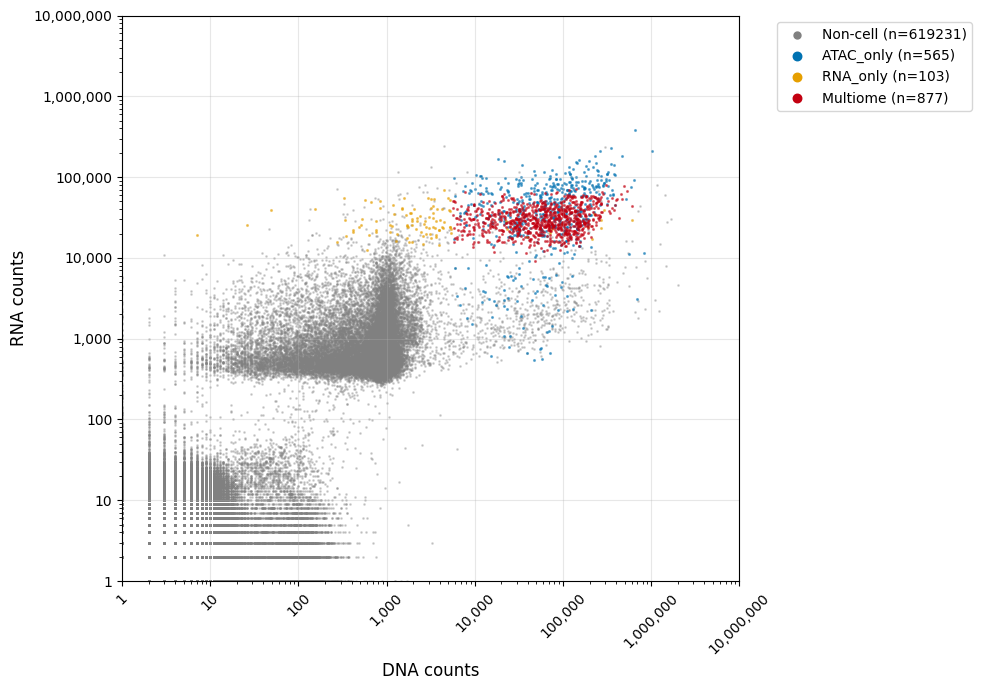

COLO829_rep1


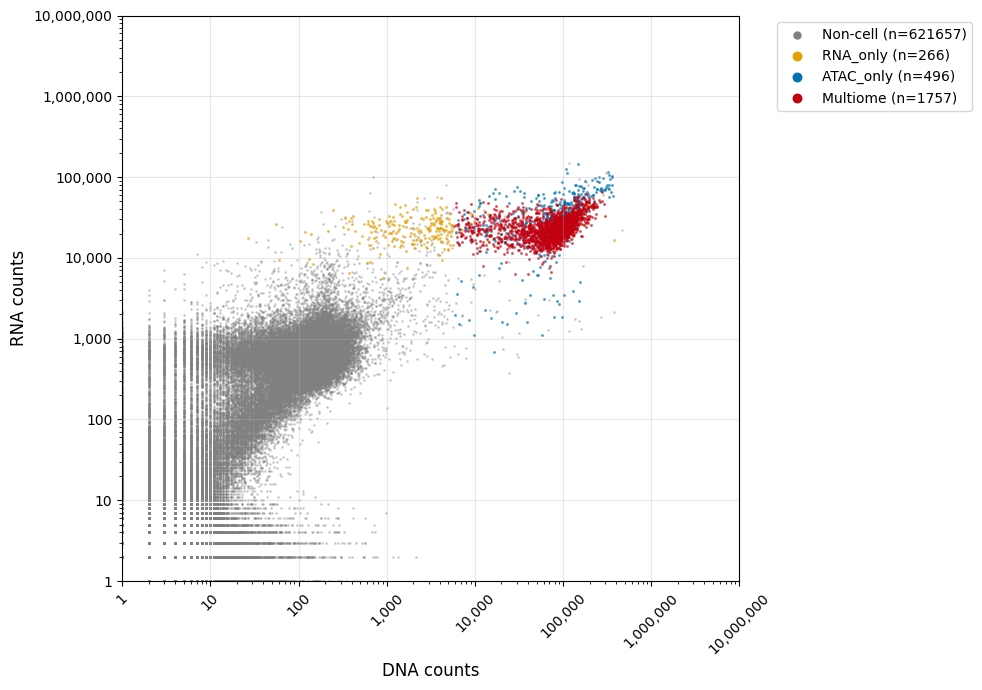

COLO829_rep2


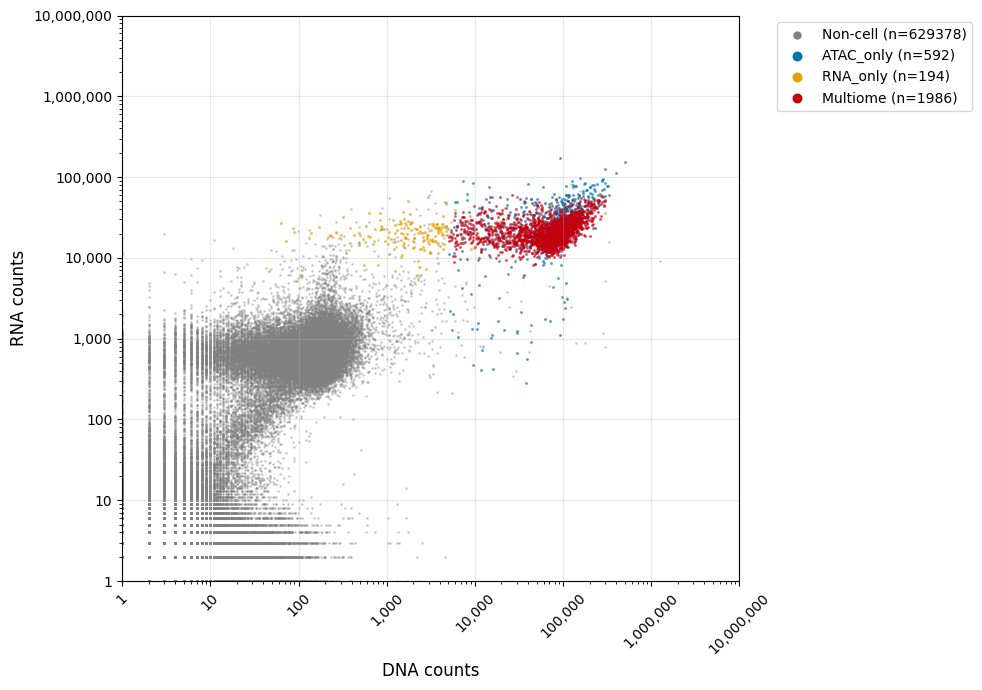

In [ ]:
for sample_name, dict_sample in dict_samples.items():
    print(sample_name)
    
    plot_dna_rna_scatter(f'/scdnalong/COLO_data/results/{sample_name}/flexiplex/flexiplex_barcodes_counts.txt',
                     f'/scnanoseq/COLO_data/results/{sample_name}/blaze/{sample_name}.bc_count.txt', f'figures/scatterplot_rasterised_{sample_name}.pdf', 
                    dna_barcodes, rna_barcodes, matched_barcodes,dict_sample)

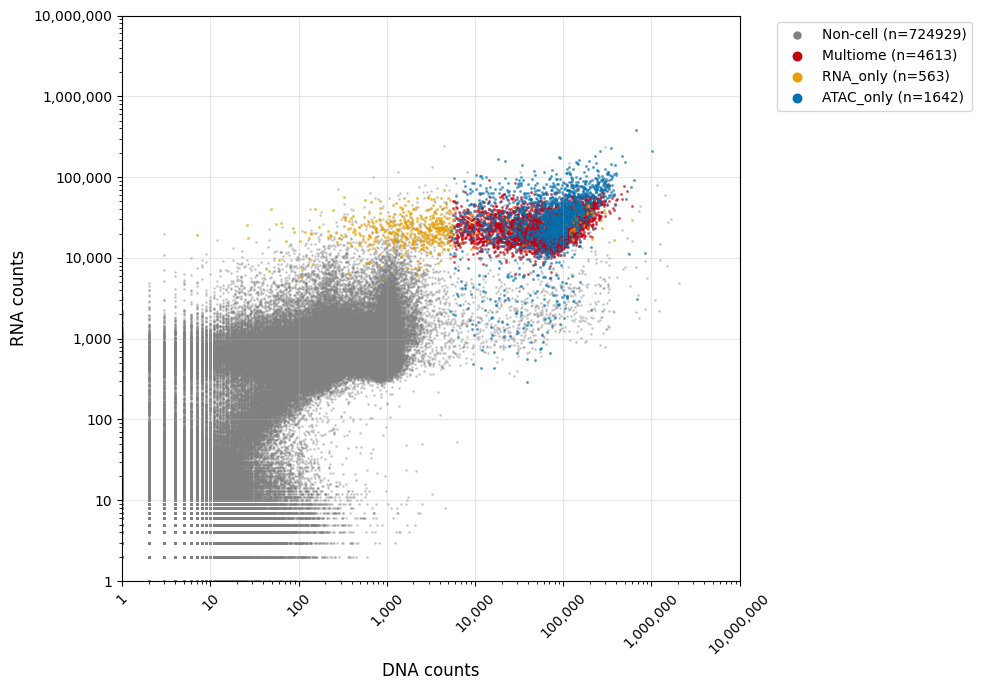

In [ ]:
from matplotlib.ticker import FuncFormatter


def plot_dna_rna_scatter_combined(dict_samples, output_file, dna_barcodes, rna_barcodes, matched_barcodes):
    """
    Create a scatter plot comparing DNA and RNA counts across ALL samples combined,
    without preserving sample name information.
    """
    barcode_map = dict(zip(matched_barcodes['cDNA_barcode'], matched_barcodes['atac_barcode']))
    
    all_dfs = []
    for sample_name, multiome_info in dict_samples.items():
        dna = pd.read_csv(f'/scdnalong/COLO_data/results/{sample_name}/flexiplex/flexiplex_barcodes_counts.txt',
                          sep='\t', header=None, names=['CB', 'count_dna'])
        rna = pd.read_csv(f'/scnanoseq/COLO_data/results/{sample_name}/blaze/{sample_name}.bc_count.txt',
                          header=None, names=['CB_rna', 'count_rna'])

        dna = dna[dna['CB'].isin(dna_barcodes[0])]
        rna = rna[rna['CB_rna'].isin(rna_barcodes[0])]

        rna['CB'] = rna['CB_rna'].map(barcode_map)
        dna_rna = pd.merge(dna, rna[['CB', 'count_rna']], on='CB', how='outer')
        dna_rna['count_dna'] = dna_rna['count_dna'].fillna(0)
        dna_rna['count_rna'] = dna_rna['count_rna'].fillna(0)
        dna_rna = pd.merge(dna_rna, multiome_info[['CB', '_merge']], on='CB', how='left')

        all_dfs.append(dna_rna)

    # Combine all samples, drop duplicate CBs keeping first occurrence
    # Combine all samples
    combined = pd.concat(all_dfs, ignore_index=True)

    # Sum counts per CB across samples
    combined_counts = combined.groupby('CB', as_index=False).agg(
    count_dna=('count_dna', 'sum'),
    count_rna=('count_rna', 'sum')
    )

    # Resolve _merge label per CB: take the highest priority label
    # Convert to plain string to avoid Categorical issues
    combined['_merge'] = combined['_merge'].astype(str).replace('nan', np.nan)

    # Resolve _merge label per CB: take the highest priority label
    merge_priority = {'Multiome': 0, 'RNA_only': 1, 'ATAC_only': 2}
    combined['_merge_rank'] = combined['_merge'].map(merge_priority).fillna(999)
    combined_merge = (combined.sort_values('_merge_rank')
                          .drop_duplicates(subset='CB', keep='first')[['CB', '_merge']])

    # Join summed counts with resolved _merge labels
    combined = pd.merge(combined_counts, combined_merge, on='CB', how='left')

    # --- Plotting ---
    plt.figure(figsize=(10, 7))

    nan_mask = combined['_merge'].isna()
    nan_data = combined[nan_mask]
    non_nan_data = combined[~nan_mask]

    if len(nan_data) > 0:
        plt.scatter(nan_data['count_dna'] + 1, nan_data['count_rna'] + 1,
                    c='grey', alpha=0.3, s=1,
                    label=f'Non-cell (n={len(nan_data)})', rasterized=True)

    color_map = {
        'Multiome':  '#c30010',
        'RNA_only':  '#E69F00',
        'ATAC_only': '#0072B2'
    }

    for merged_val in non_nan_data['_merge'].unique():
        subset = non_nan_data[non_nan_data['_merge'] == merged_val]
        plt.scatter(subset['count_dna'] + 1, subset['count_rna'] + 1,
                    c=color_map.get(merged_val, 'black'),
                    alpha=0.5, s=1.5,
                    label=f'{merged_val} (n={len(subset)})', rasterized=True)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1, 10000000)
    plt.ylim(1, 10000000)

    formatter = FuncFormatter(lambda x, p: f"{x:,.0f}")
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)

    plt.xlabel('DNA counts', fontsize=12)
    plt.ylabel('RNA counts', fontsize=12)
    plt.xticks(rotation=45)

    leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
    for h in leg.legendHandles:
        h.set_alpha(1)

    plt.grid(True, alpha=0.3)
    plt.gca().set_facecolor('white')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# Call once for all samples
plot_dna_rna_scatter_combined(
    dict_samples=dict_samples,
    output_file='figures/scatterplot_rasterised_combined.pdf',
    dna_barcodes=dna_barcodes,
    rna_barcodes=rna_barcodes,
    matched_barcodes=matched_barcodes
)

In [104]:
pip list

Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                     